In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf               

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
# Royal Bank of Canada (TSX: RY)
ticker = "RY.TO"  # .TO = Toronto Stock Exchange
data = yf.download(ticker, start="2020-01-01", end="2026-03-20")

[*********************100%***********************]  1 of 1 completed


In [4]:
print(data.head())
print(f"Data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")

Price           Close       High        Low       Open   Volume
Ticker          RY.TO      RY.TO      RY.TO      RY.TO    RY.TO
Date                                                           
2020-01-02  81.429741  81.500512  80.910727  81.225280  1354100
2020-01-03  81.130943  81.374726  80.729893  80.910758  3199000
2020-01-06  81.146660  81.162385  80.753469  80.792785  3139000
2020-01-07  81.178116  81.555575  81.091613  81.351115  1289100
2020-01-08  81.822929  82.184664  81.099454  81.162366  4035100
Data shape: (1560, 5)
Date range: 2020-01-02 00:00:00 to 2026-03-19 00:00:00


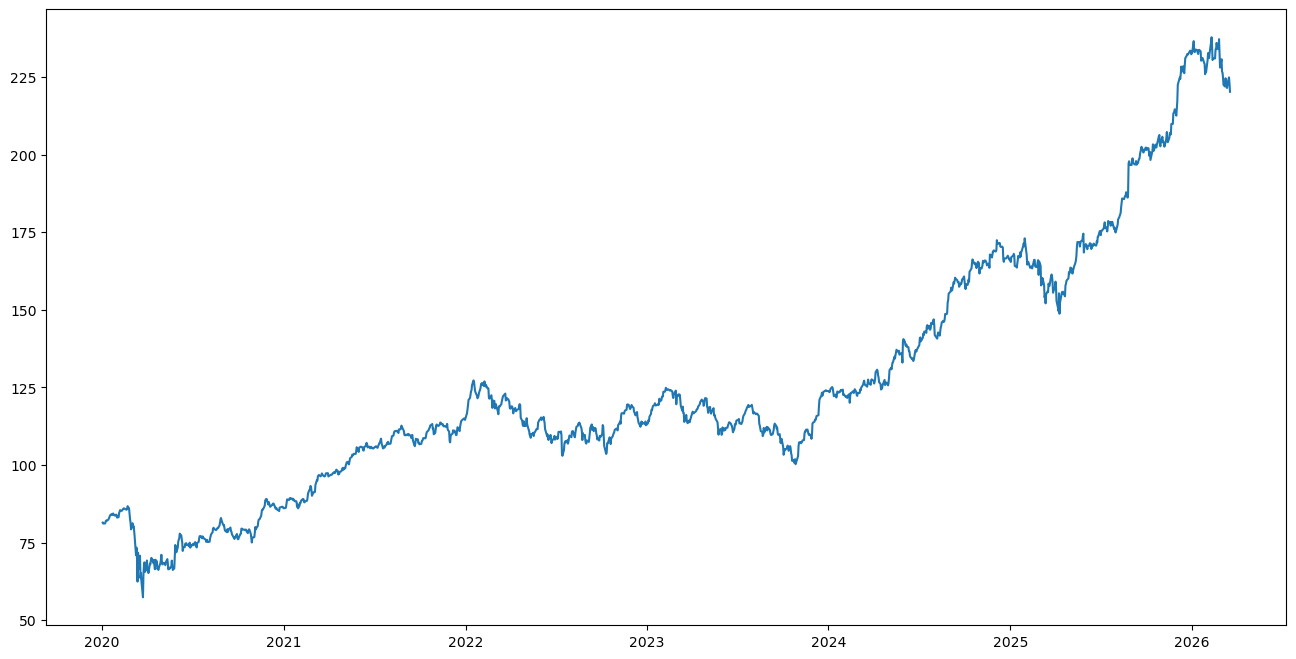

In [5]:
plt.figure(figsize=(16,8))
plt.plot(data['Close'], label='Closing Price')

In [6]:
data['Open - Close'] = data['Open'] - data['Close']
data['High - Low'] = data['High'] - data['Low']
data = data.dropna() 

In [7]:
X = data[['Open - Close', 'High - Low']]
X.head()

Price,Open - Close,High - Low
Ticker,,
Date,,
2020-01-02,-0.204461,0.589786
2020-01-03,-0.220186,0.644832
2020-01-06,-0.353875,0.408915
2020-01-07,0.172999,0.463962
2020-01-08,-0.660563,1.085209


In [12]:
Y = np.where(data['Close'].shift(-1)>data['Close'],1,-1).ravel()

In [13]:
Y

array([-1,  1,  1, ..., -1, -1, -1], shape=(1560,))

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state = 44)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

#using gridsearch to find the best parameter
params = {'n_neighbors' :[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn = neighbors.KNeighborsClassifier()
model = GridSearchCV(knn, params, cv=5)

#fit the model
model.fit(X_train, y_train)

#Accuracy Score
accuracy_train = accuracy_score(y_train, model.predict(X_train))
accuracy_test = accuracy_score(y_test, model.predict(X_test))

print ('Train_data Accuracy: %.2f' %accuracy_train)
print('Test_data Accuracy: %.2f' %accuracy_test)


Train_data Accuracy: 0.63
Test_data Accuracy: 0.48


In [16]:
predictions_classification = model.predict(X_test)

In [19]:
actual_predicted_data = pd.DataFrame({'Actual Class':y_test, 'Predicted Class':predictions_classification})

In [20]:
actual_predicted_data.head(10)

,Actual Class,Predicted Class
0,1,-1
1,-1,1
2,1,1
3,-1,1
4,-1,1
5,-1,1
6,-1,1
7,1,1
8,-1,-1
9,1,-1


In [21]:
from sklearn.metrics import confusion_matrix, classification_report 
import seaborn as sns 
import matplotlib.pyplot as plt 

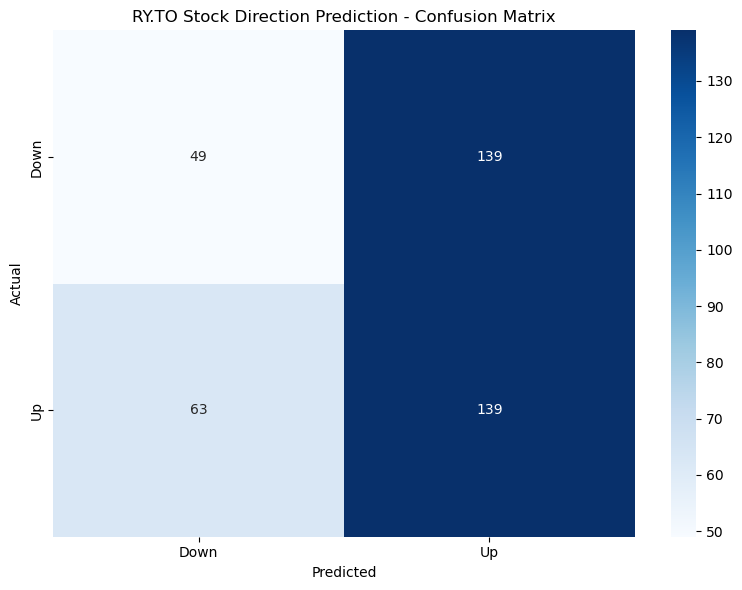

In [22]:
#Confusion Matrix 
cm = confusion_matrix(y_test, predictions_classification)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('RY.TO Stock Direction Prediction - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_ry.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
from sklearn.metrics import classification_report
print("RY.TO Stock Prediction Results")
print("="*40)
print(classification_report(y_test, predictions_classification, target_names=['Down (-1)', 'Up (1)']))

RY.TO Stock Prediction Results
              precision    recall  f1-score   support

   Down (-1)       0.44      0.26      0.33       188
      Up (1)       0.50      0.69      0.58       202

    accuracy                           0.48       390
   macro avg       0.47      0.47      0.45       390
weighted avg       0.47      0.48      0.46       390



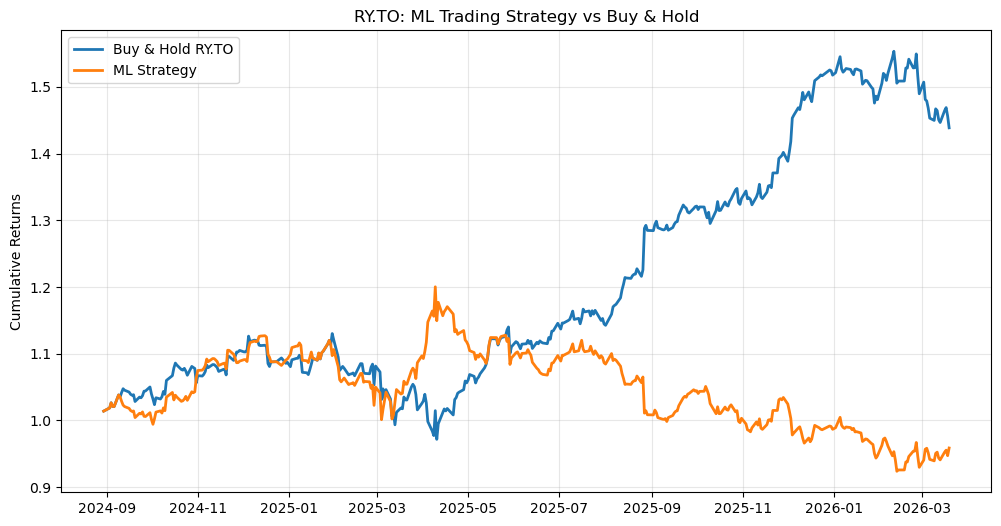

In [35]:
# Fix MultiIndex - get Close prices as single column
test_dates = data.index[-len(y_test):]
close_prices = data['Close']['RY.TO'].loc[test_dates]  # Access MultiIndex properly
data_test = pd.DataFrame({'Close': close_prices})
data_test['Predicted'] = predictions_classification
data_test['Actual'] = y_test

# Simple multiplication using numpy
returns = data_test['Close'].pct_change()
data_test['Strategy_Return'] = pd.Series(returns.values * data_test['Predicted'].values, index=data_test.index)

data_test['Cumulative_Market'] = (1 + returns).cumprod()
data_test['Cumulative_Strategy'] = (1 + data_test['Strategy_Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(data_test['Cumulative_Market'], label='Buy & Hold RY.TO', linewidth=2)
plt.plot(data_test['Cumulative_Strategy'], label='ML Strategy', linewidth=2)
plt.title('RY.TO: ML Trading Strategy vs Buy & Hold')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('backtest_ry.png', dpi=300, bbox_inches='tight')
plt.show()


In [36]:
strategy_return = data_test['Strategy_Return'].sum()
market_return = data_test['Close'].pct_change().sum()

print("\n" + "="*60)
print("RY.TO STOCK DIRECTION PREDICTOR - RESULTS")
print("="*60)
print(f"Model: KNN (K={model.best_params_['n_neighbors']})")
print(f"Test Accuracy: {accuracy_test:.2%}")
print(f"Strategy Return: {strategy_return:.2%}")
print(f"Buy & Hold: {market_return:.2%}")
print("="*60)



RY.TO STOCK DIRECTION PREDICTOR - RESULTS
Model: KNN (K=15)
Test Accuracy: 48.21%
Strategy Return: -2.36%
Buy & Hold: 38.23%


In [37]:
actual_predicted_data.to_csv('ry_predictions.csv', index=False)
print("Portfolio ready! Files saved:")
print("- backtest_ry.png")
print("- confusion_matrix_ry.png") 
print("- ry_predictions.csv")
print("\nUpload to GitHub + your notebook = Job-ready project!")


Portfolio ready! Files saved:
- backtest_ry.png
- confusion_matrix_ry.png
- ry_predictions.csv

Upload to GitHub + your notebook = Job-ready project!
